In [2]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import pandas as pd
import numpy as np
import seaborn as sns
import gseapy as gp
from gseapy import gseaplot

In [3]:
import scanpy as sc

adata = sc.read_h5ad(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\ResolVI_subclusters.h5ad")
#only considering dorsal epi/dermis
adata = adata[adata.obs['compartment'].str.contains('orsal')]
adata.obs.compartment.unique()

['dorsal_dermis', 'dorsal_epidermis']
Categories (2, object): ['dorsal_dermis', 'dorsal_epidermis']

In [3]:
#run if checking celltypes only
celltype_adatas = {}

cell_type_list = ['basal_KC', 'activated_basal_KC', 'suprabasal_KC', 'activated_subrabasal_KC', 'corneocyte', 'activated_corneocyte']

for type in cell_type_list:
    celltype_adatas[type] = adata[adata.obs['celltype_assignments'] == type].copy()

In [4]:
from pathlib import Path
#results_path = Path(r"C:\Users\dbuxton\OneDrive\Desktop\biochem\Year 4\Thesis\results figures or slides\DESEQ_results")
results_path = Path(r"C:\Users\dbuxton\Desktop")

In [5]:
#bulk compartment

import decoupler as dc

#making pseudobulk objects for the epidermis
adata_epi = adata[adata.obs['compartment'].str.contains('_epidermis')].copy()

##Filtering genes not expressed by at least 1% of cells
min_cells = int(0.01 * adata_epi.n_obs)
sc.pp.filter_genes(adata_epi, min_cells=min_cells)


big_bulk_epidermis = dc.pp.pseudobulk(
    adata_epi,
    sample_col = 'batch_key', #defines replicates
    groups_col = None, #ignore if using batch_key, add in if using celltypes
    layer = None,
    mode = 'sum',
    empty = True
)


#making pseudobulk objects for the dermis
adata_derm = adata[adata.obs['compartment'].str.contains('_dermis')].copy()

##Filtering genes not expressed by at least 1% of cells
min_cells = int(0.01 * adata_derm.n_obs)
sc.pp.filter_genes(adata_derm, min_cells=min_cells)

big_bulk_dermis = dc.pp.pseudobulk(
    adata_derm,
    sample_col = 'batch_key', #defines replicates
    groups_col = None, #ignore if using batch_key, add in if using celltypes
    layer = None,
    mode = 'sum',
    empty = True
)

d:\Dom\Virtual_Environments\napari_registration_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [29]:
#If not separating male/female objects (considering together)

bulk_subtypes = {'big_bulk_epidermis':big_bulk_epidermis, 'big_bulk_dermis':big_bulk_dermis}


In [5]:
#individual celltypes
import decoupler as dc

bulk_subtypes = {}

for name, adata in celltype_adatas.items():
    #making pseudobulk objects for the epidermis
    adata_epi = adata[adata.obs['compartment'].str.contains('_epidermis')].copy()

    ##Filtering genes not expressed by at least 1% of cells
    min_cells = int(0.01 * adata_epi.n_obs)
    sc.pp.filter_genes(adata_epi, min_cells=min_cells)


    bulk_subtypes[f'{name}_epi'] = dc.pp.pseudobulk(
        adata_epi,
        sample_col = 'batch_key', #defines replicates
        groups_col = None, #ignore if using batch_key, add in if using celltypes
        layer = None,
        mode = 'sum',
        empty = True
    )


    #making pseudobulk objects for the dermis
    adata_derm = adata[adata.obs['compartment'].str.contains('_dermis')].copy()

    ##Filtering genes not expressed by at least 1% of cells
    min_cells = int(0.01 * adata_derm.n_obs)
    sc.pp.filter_genes(adata_derm, min_cells=min_cells)

    bulk_subtypes[f'{name}_derm'] = dc.pp.pseudobulk(
        adata_derm,
        sample_col = 'batch_key', #defines replicates
        groups_col = None, #ignore if using batch_key, add in if using celltypes
        layer = None,
        mode = 'sum',
        empty = True
    )

d:\Dom\Virtual_Environments\napari_registration_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3824.0_x64__qbz5n2kfra8p0\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3824.0_x64__qbz5n2kfra8p0\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [26]:
#check how many genes left after filtering
print(len(big_bulk_dermis.var))
print(len(big_bulk_epidermis.var))


937
2144


## Sorting out gene names

In [25]:
gene_panel = pd.read_csv(r"C:\Users\dbuxton\Downloads\XeniumPrimeMouse5Kpan_tissue_pathways_metadata.csv", index_col = 0)
gene_panel.head(1)

,gene_id,num_codewords,num_probesets,protein_name,location,cell_type,cellchat_pathway
gene_name,,,,,,,
A1cf,ENSMUSG00000052595,2,2,APOBEC1 complementation factor (APOBEC1-stimul...,Nucleus,NaN,NaN


In [21]:
mechano_genes = pd.read_csv(r"C:\Users\dbuxton\Downloads\Mechanobiology_panel_combined_with_mouse 2(Panel).csv", index_col = 2)
mechano_genes.index

Index(['Cdh1', 'Cdh2', 'Cdh3', 'Cdh6', 'Cdh11', 'Cdh13', 'Cldn1', 'Cldn4',
       'Cldn7', 'Ctnna1',
       ...
       'Lef1', 'Lgr4', 'Lrp5', 'Nfatc1', 'Prickle1', 'Ror2', 'Vangl2', 'Wnt5a',
       'Wnt5b', 'Wnt11'],
      dtype='object', name='mouse gene', length=637)

In [27]:
df_in5k = mechano_genes[['family']]
df_in5k = df_in5k[df_in5k.index.isin(gene_panel.index)]
df_in5k

,family
mouse gene,
Cdh1,Cadherin / junction
Cdh2,Cadherin / junction
Cdh3,Cadherin / junction
Cdh6,Cadherin / junction
Cdh11,Cadherin / junction
...,...
Ror2,Wnt / planar cell polarity (mechano)
Vangl2,Wnt / planar cell polarity (mechano)
Wnt5a,Wnt / planar cell polarity (mechano)


In [28]:
df_in5k

,family
mouse gene,
Cdh1,Cadherin / junction
Cdh2,Cadherin / junction
Cdh3,Cadherin / junction
Cdh6,Cadherin / junction
Cdh11,Cadherin / junction
...,...
Ror2,Wnt / planar cell polarity (mechano)
Vangl2,Wnt / planar cell polarity (mechano)
Wnt5a,Wnt / planar cell polarity (mechano)


## Running the DESEQ

In [30]:
import matplotlib.pyplot as plt

valid_genes_list = {}

for name, bulk in bulk_subtypes.items():
    #make a deseq data set from your anndata
    
    ###avoid recalculating if already done###
    # if Path(results_path/ f'{name}_Ctrl_D3IMQ_DEgenes.csv').exists(): #bit jammy, but if D3 is calced, then so are D7/D10
    #     continue

    dds = DeseqDataSet(counts = bulk.X,
                   metadata = bulk.obs,
                   design_factors = 'condition')
    dds.var = bulk.var


    #run deseq2 on it
    try:
        dds.deseq2()
    except ValueError as e:
        print(f'{e}_{name} failed :(')
        continue

    #get the stats
    for day in ['D7IMQ']:

        stat_res = DeseqStats(dds, contrast = ['condition', day, 'Ctrl']) #pairwise comparison of days with each condition
        stat_res.summary()
        #get diffexp dataframe
        res = stat_res.results_df
        res_file = f'{name}_Ctrl_{day}_DEgenes.csv'
        #res.to_csv(results_path / res_file) #save table with stats of DE genes
        
        #filtering any genes with baseMean <10, choice is somewhat arbitrary
        res = res[res.baseMean >10]
        #then filter all those that are not significant or large enough
        sigs = res[(abs(res.log2FoldChange) > 1)&(res.padj <0.05)] #again, log2fc threshold is bit arbitrary,being stringent so using 1.

        
        
        # #plot CLUSTERMAP for significant genes
        cluster_map_name = f'{name}_wholemechano2_cluster.png'
        cluster_map_path = results_path / 'clustermaps' / cluster_map_name
        if len(sigs) >2:
            dds.layers['log1p'] = np.log1p(dds.layers['normed_counts'])
            #check for valid genes
            valid_genes = [g for g in df_in5k.index if g in dds.var_names]

     

            dds_sigs = dds[:, valid_genes].copy()

            grapher = pd.DataFrame(dds_sigs.layers['log1p'].T,
                        index = dds_sigs.var_names, columns = dds_sigs.obs_names)
            
            #adding colours to the gene families
            family_lookup = df_in5k['family']

            families = family_lookup.loc[valid_genes].unique()
            palette = sns.husl_palette(n_colors = len(families))
            family_colour_map = dict(zip(families, palette))

            row_colours = family_lookup.loc[dds_sigs.var_names].map(family_colour_map)
            row_colours.name = 'Family'
            #######


            clustermap = sns.clustermap(grapher, z_score = 0, cmap = 'RdYlBu_r',
                                    yticklabels = True,
                                    row_colors = row_colours,
                                    figsize = (15.7, 27))
            clustermap.ax_heatmap.tick_params(axis = 'y', labelsize = '13')
            clustermap.ax_heatmap.tick_params(axis = 'x', labelsize = '20')

            for tick_label in clustermap.ax_heatmap.axes.get_yticklabels():
                gene = tick_label.get_text()
                fam = family_lookup.loc[gene]
                tick_label.set_color(family_colour_map[fam])

            #build a key for colours
            from matplotlib.patches import Patch
            legend_handles = [Patch(facecolor = family_colour_map[fam], label = fam) for fam in families]
            clustermap.ax_heatmap.legend(handles = legend_handles, fontsize = 18, title = 'Gene Function', title_fontsize = 30, bbox_to_anchor = (1.25, 1), loc = 'upper left', borderaxespad = 0)


            clustermap.savefig(cluster_map_path, bbox_inches = 'tight', dpi = 400)
            plt.close(clustermap.fig)
        else:
            print(f'{name} failed at clustermapping')


C:\Users\dbuxton\AppData\Local\Temp\ipykernel_34532\631845267.py:12: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(counts = bulk.X,
Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.39 seconds.

Fitting dispersion trend curve...
d:\Dom\Virtual_Environments\napari_registration_project\.venv\Lib\site-packages\pydeseq2\dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 0.43 seconds.

Fitting LFCs...
... done in 0.33 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.29 seconds.



Log2 fold change & Wald test p-value: condition D7IMQ vs Ctrl
            baseMean  log2FoldChange     lfcSE      stat        pvalue  \
Aatf       89.649090       -0.390327  0.161874 -2.411301  1.589571e-02   
Abca1      45.415647       -0.824275  0.235144 -3.505411  4.559037e-04   
Abca3      44.003672       -1.797402  0.298026 -6.031027  1.629209e-09   
Abca7     109.373211       -0.866994  0.116148 -7.464572  8.357057e-14   
Abcb8      21.522924        1.499170  0.344618  4.350230  1.359947e-05   
...              ...             ...       ...       ...           ...   
Zfyve9     34.230270       -0.045068  0.209189 -0.215442  8.294224e-01   
Zkscan1    35.886741       -0.727993  0.189778 -3.836023  1.250425e-04   
Zmpste24   29.303583        0.447488  0.274523  1.630055  1.030898e-01   
Zmynd19    22.545709       -0.436927  0.277497 -1.574532  1.153645e-01   
Zzef1      58.518522       -0.279102  0.151790 -1.838744  6.595291e-02   

                  padj  
Aatf      3.095404e-02  

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_34532\631845267.py:12: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(counts = bulk.X,
Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.21 seconds.

Fitting dispersion trend curve...
d:\Dom\Virtual_Environments\napari_registration_project\.venv\Lib\site-packages\pydeseq2\dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.02 seconds.

Fitting MAP dispersions...
... done in 0.21 seconds.

Fitting LFCs...
... done in 1.22 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.24 seconds.



Log2 fold change & Wald test p-value: condition D7IMQ vs Ctrl
          baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
Aatf     24.769587       -0.621409  0.255214 -2.434859  0.014898  0.054957
Abca1    69.097989        0.142823  0.184609  0.773651  0.439137  0.636952
Abca7    32.742050       -0.096628  0.202617 -0.476896  0.633436  0.780960
Abcc1    15.353058       -0.173442  0.302050 -0.574216  0.565822  0.725274
Abcf1    17.292778       -0.591944  0.258074 -2.293697  0.021808  0.072832
...            ...             ...       ...       ...       ...       ...
Zc3h11a  20.562554       -0.159566  0.253425 -0.629640  0.528930  0.705994
Zdhhc8   16.875022       -0.521512  0.264198 -1.973942  0.048388  0.132186
Zeb2     30.637227        0.068855  0.217034  0.317256  0.751050  0.855941
Zfp106   28.295164       -0.286218  0.233588 -1.225312  0.220458  0.399553
Zzef1    16.995262        0.513974  0.291399  1.763813  0.077763  0.190539

[937 rows x 6 columns]


# violin plots across conditions - not currently working

In [1]:
import scanpy as sc

adata = sc.read_h5ad(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\ResolVI_subclusters.h5ad")
#only considering dorsal epi/dermis
adata = adata[adata.obs['compartment'].str.contains('orsal')]
adata.obs.compartment.unique()

['dorsal_dermis', 'dorsal_epidermis']
Categories (2, object): ['dorsal_dermis', 'dorsal_epidermis']

['dorsal_dermis', 'dorsal_epidermis']
Categories (2, object): ['dorsal_dermis', 'dorsal_epidermis']


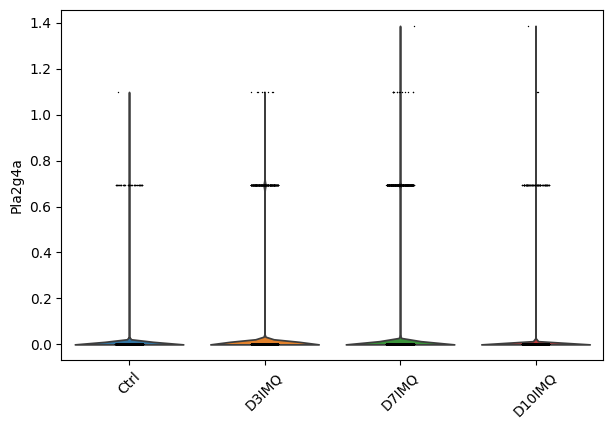

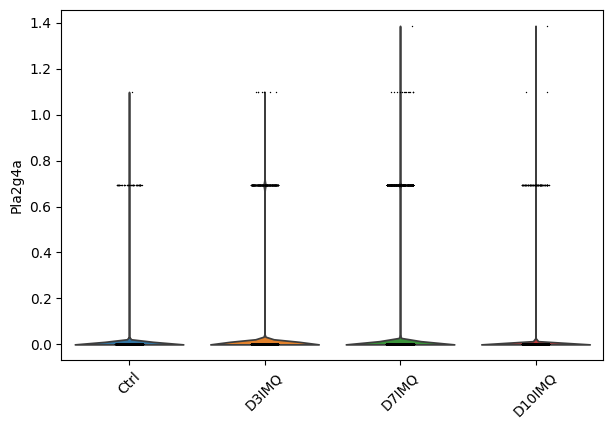

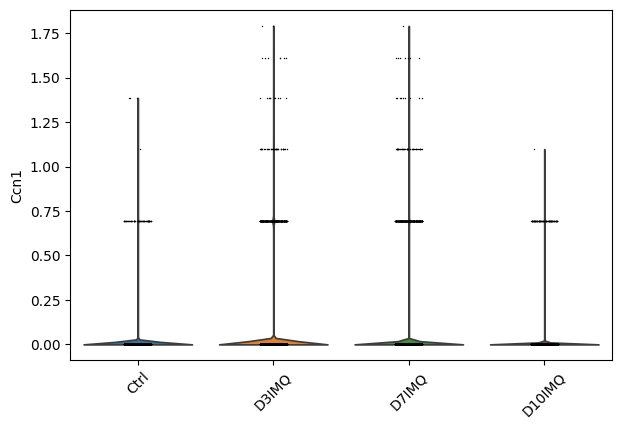

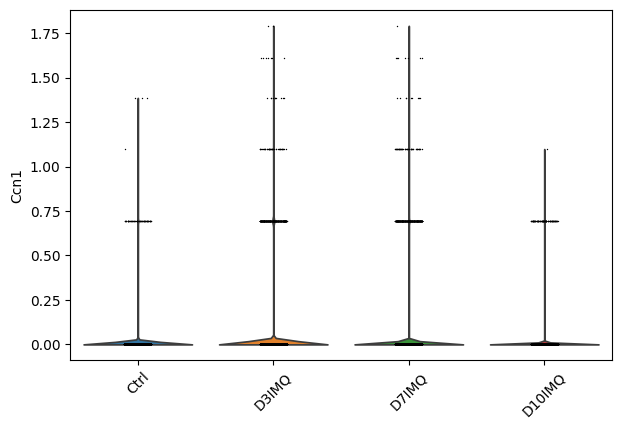

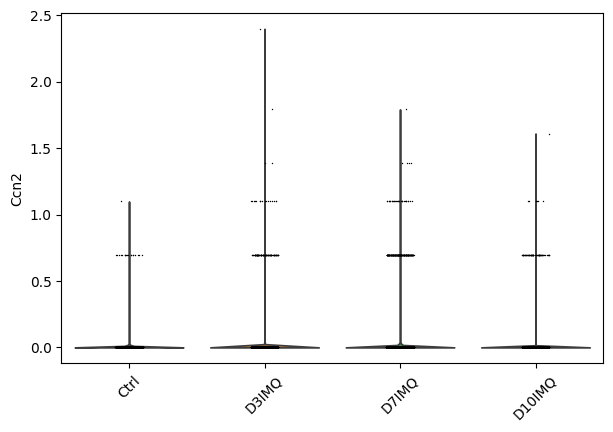

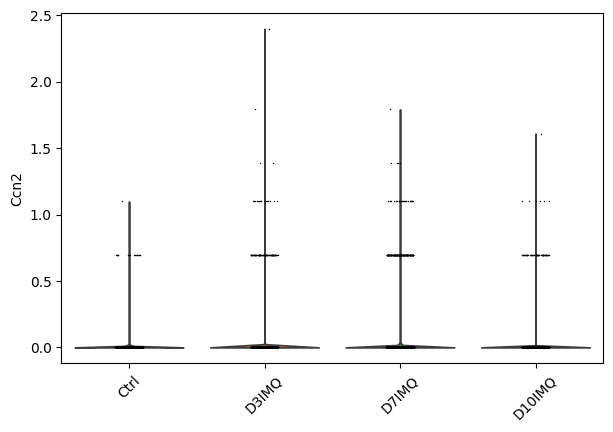

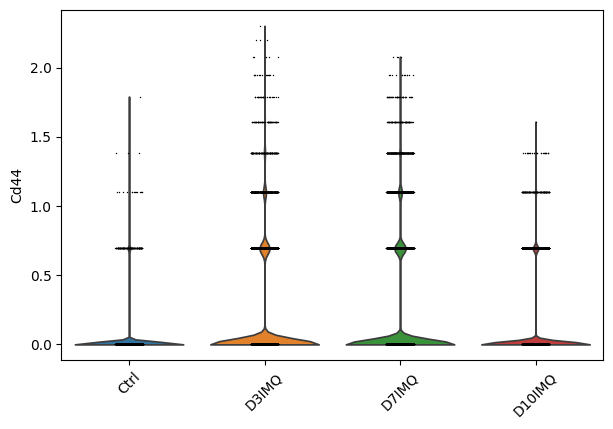

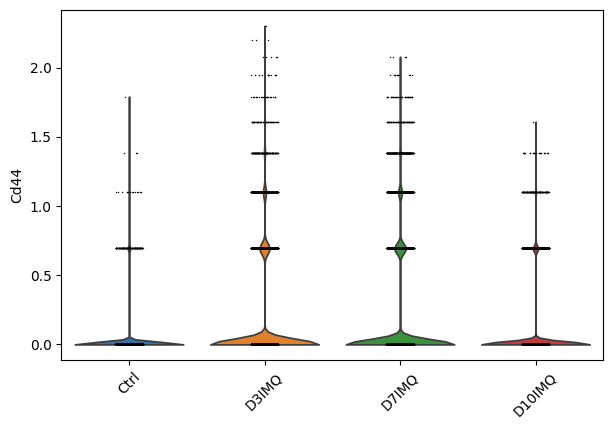

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_30888\3071479594.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_by_sample = expr_df.groupby(SAMPLE_COL)[genes_to_plot].mean()


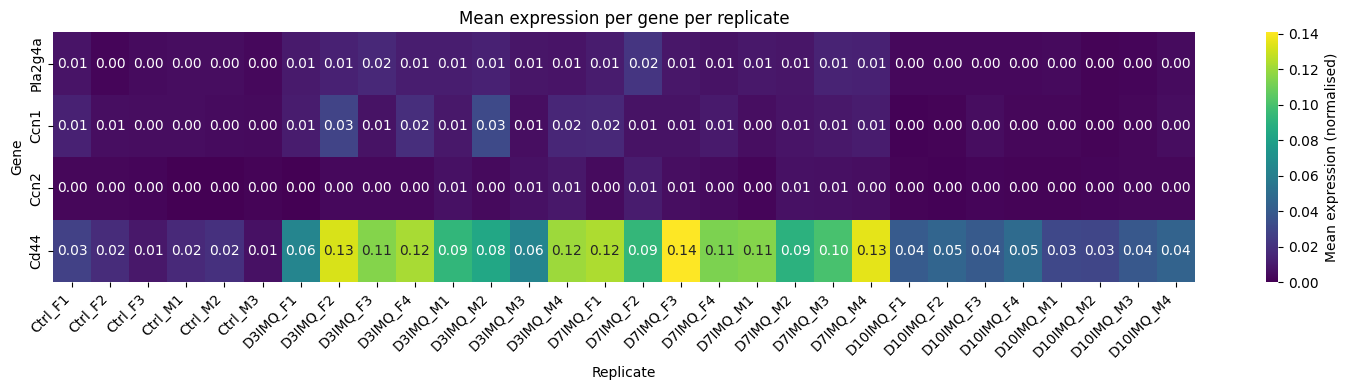

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

adata = sc.read_h5ad(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\ResolVI_subclusters.h5ad")

# only considering dorsal epi/dermis
adata = adata[adata.obs['compartment'].str.contains('orsal')].copy()
print(adata.obs['compartment'].unique())

# ---- CONFIG ----
LAYER_KEY = 'normalised'       # confirmed
SAMPLE_COL = 'batch_key'       # confirmed, holds e.g. 'Ctrl_F1', 'D7IMQ_M4'
CONDITION_ORDER = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']
genes_to_plot = ['Pla2g4a', 'Ccn1', 'Ccn2', 'Cd44']

# sanity check genes exist
missing = [g for g in genes_to_plot if g not in adata.var_names]
if missing:
    raise ValueError(f"These genes are not in adata.var_names: {missing}")

# derive 'condition' from batch_key, since it's not a separate column
# assumes format like 'Ctrl_F1', 'D7IMQ_M4' -> splits on first underscore
adata.obs['condition'] = adata.obs[SAMPLE_COL].str.split('_').str[0]
adata.obs['condition'] = adata.obs['condition'].astype('category')
adata.obs['condition'] = adata.obs['condition'].cat.reorder_categories(
    [c for c in CONDITION_ORDER if c in adata.obs['condition'].cat.categories]
)

# ============================================================
# (a) Violin plots — one per gene, aggregated across replicates and sex,
#     one violin per condition
# ============================================================
for gene in genes_to_plot:
    for compartment in ["dorsal_dermis", "dorsal_epidermis"]:
        bdata = adata[adata.obs.compartment == compartment].copy()
        sc.pl.violin(
            adata,
            keys=gene,
            groupby='condition',
            layer=LAYER_KEY,
            rotation=45,
            show=True,
        )
    # to save instead of/as well as showing:
    # ax = sc.pl.violin(adata, keys=gene, groupby='condition', layer=LAYER_KEY,
    #                    rotation=45, show=False)
    # ax.figure.savefig(f"violin_{gene}.png", dpi=300, bbox_inches='tight')

# ============================================================
# (b) Heatmap — mean expression per gene per replicate (not aggregated by condition)
# ============================================================
expr = adata[:, genes_to_plot].layers[LAYER_KEY]
if not isinstance(expr, np.ndarray):
    expr = expr.toarray()  # handle sparse matrices

expr_df = pd.DataFrame(expr, columns=genes_to_plot, index=adata.obs_names)
expr_df[SAMPLE_COL] = adata.obs[SAMPLE_COL].values

# mean expression per gene, per sample/replicate
mean_by_sample = expr_df.groupby(SAMPLE_COL)[genes_to_plot].mean()

# order columns by condition order, then alphabetically within condition
def sort_key(sample_name):
    cond = sample_name.split('_')[0]
    cond_rank = CONDITION_ORDER.index(cond) if cond in CONDITION_ORDER else len(CONDITION_ORDER)
    return (cond_rank, sample_name)

mean_by_sample = mean_by_sample.loc[sorted(mean_by_sample.index, key=sort_key)]

plt.figure(figsize=(max(6, len(mean_by_sample) * 0.5), 4))
sns.heatmap(
    mean_by_sample.T,           # genes as rows, replicates as columns
    cmap='viridis',
    annot=True,
    fmt='.2f',
    cbar_kws={'label': f'Mean expression ({LAYER_KEY})'},
)
plt.xlabel('Replicate')
plt.ylabel('Gene')
plt.title('Mean expression per gene per replicate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()